# Dataset: gör, seç, dinle

1. **İşlenmiş dataset klasörünü** seç: `train.npz`, `validation.npz`, `test.npz` içeren HVO export.
2. Rastgele ya da indeksle örnek seç; piano roll'u gör ve ▶ ile dinle.
3. Elenen dosya/pencereleri nedenleriyle incele.

Kernel: **v2/.venv/bin/python**. Hücreleri sırayla çalıştır. Veri dosyaları değiştirilmez.
Audio, timing/velocity'yi koruyan basit sentezlenmiş davul önizlemesidir; orijinal kit/VST kaydı değildir.


In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Audio, Markdown

cwd = Path.cwd().resolve()
V2 = next((p for root in [cwd, *cwd.parents] for p in [root, root/'v2'] if (p/'groove/ingest').is_dir()), None)
if V2 is None:
    raise FileNotFoundError('Kernel çalışma dizini proje kökü, v2 veya v2/notebooks olmalı.')
sys.path.insert(0, str(V2))
from groove.ingest.explore import split_files, example, provenance, canonical_run, rejected, read_record, piano_roll, preview_audio
def local(value):
    p = Path(value).expanduser()
    return p if p.is_absolute() else V2/p
pd.set_option('display.max_colwidth', 140)


## 1 · İşlenmiş dataset klasörü

Göreli yollar `v2/` içindir. `CANONICAL_RUN` normalde otomatik bulunur; dataset'i
başka bilgisayara taşıdıysan elenen dosyaları görmek için run'ın yeni yolunu yaz.


In [2]:
DATASET_DIR = 'data/unified-hvo-fill-aware-final'
CANONICAL_RUN = None

DATASET = local(DATASET_DIR)
contents = split_files(DATASET)
if not contents:
    raise FileNotFoundError(f'{DATASET}: train/validation/test.npz bulunamadı. Canonical output değil, --export-hvo klasörünü seç.')
display(pd.DataFrame(contents))
card_path = DATASET/'dataset-card.json'
card = json.loads(card_path.read_text()) if card_path.exists() else {}
print('Fill etiketleri (-1: bilinmiyor, 0: groove, 1: fill):', card.get('fill_labels', 'Bu eski export’ta yok.'))
RUN = None
try:
    RUN = canonical_run(DATASET, local(CANONICAL_RUN) if CANONICAL_RUN else None)
    print('Elenen kayıtların canonical run’ı:', RUN)
except (OSError, KeyError) as error:
    print(str(error))


,split,file,examples,shape,megabytes
0,train,train.npz,99463,"(99463, 32, 9, 3)",12.26
1,validation,validation.npz,2914,"(2914, 32, 9, 3)",0.28
2,test,test.npz,1397,"(1397, 32, 9, 3)",0.20


Fill etiketleri (-1: bilinmiyor, 0: groove, 1: fill): {'train': {'0': 4482, '1': 94981}, 'validation': {'0': 575, '1': 2339}, 'test': {'0': 567, '1': 830}}
Elenen kayıtların canonical run’ı: /Users/cagrierdem/Desktop/ongoing/POSTDOC/2groove/v2/data/unified-fill-aware/runs/20261009T095937044394Z-ebf156e7


## 2 · Örnek seç → piano roll → audio

`INDICES = None`: her çalıştırmada rastgele `N_RANDOM` örnek. Belirli örnekler için
`INDICES = [0, 12]`. `HAS_FILL = None`: hepsi; `1`: fill var; `0`: groove;
`-1`: etiketi bilinmiyor. Eski export'larda fill filtresi kullanılamaz.
Turuncu alan fill bölgesidir; yatay konum microtiming dahil gerçek beat zamanıdır.


### train · örnek 95149

,split,index,bpm,style,has_fill,fill_start_beat,fill_duration_beats,synthetic
0,train,95149,94.999992,latin,1,4.0,4.0,True


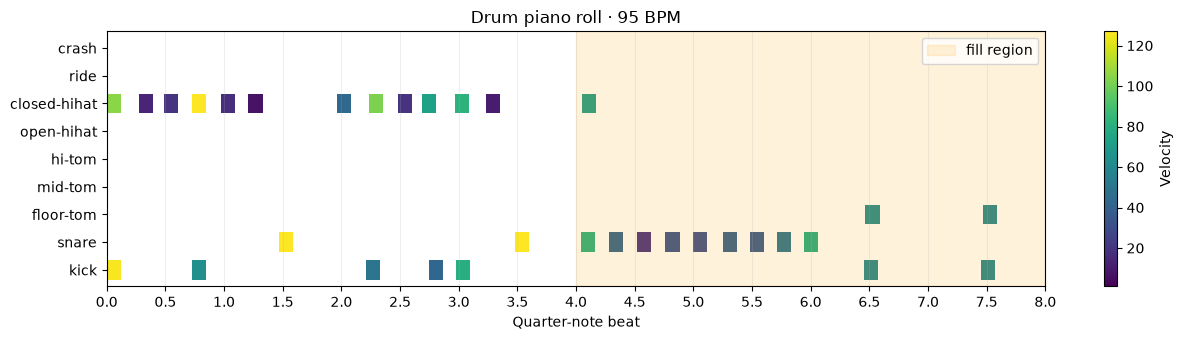

Kaynak: {'source': '15133af630f32a4f08cd98c1', 'start': 8.0, 'parent_ids': ['15133af630f32a4f08cd98c1', '1628c30d918a35e1e1379bb0'], 'fill_source': '1628c30d918a35e1e1379bb0', 'fill_boundary_basis': 'inferred_next_bar_after_last_onset', 'matched_styles': ['latin'], 'style_labels': ['latin']}


### train · örnek 78606

,split,index,bpm,style,has_fill,fill_start_beat,fill_duration_beats,synthetic
0,train,78606,117.999901,latin,1,4.0,4.0,True


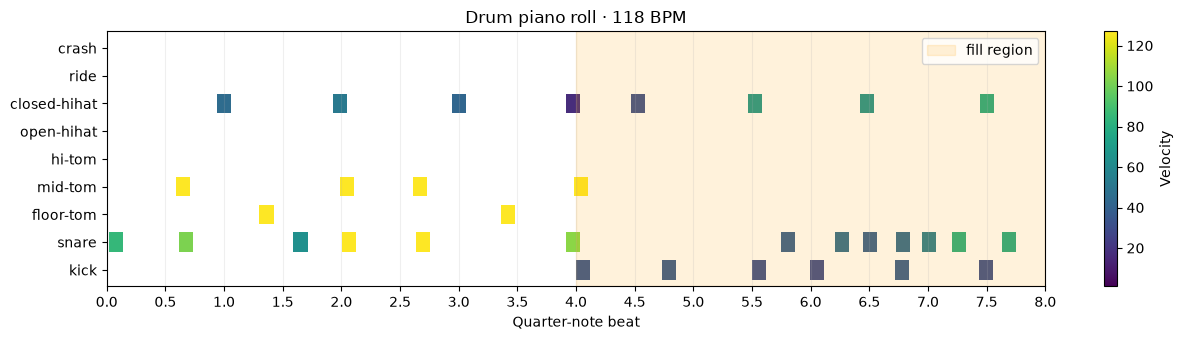

Kaynak: {'source': '6eb608eb096c3c46cb955e81', 'start': 104.0, 'parent_ids': ['6eb608eb096c3c46cb955e81', 'dea57764a2303495cc2c61e9'], 'fill_source': 'dea57764a2303495cc2c61e9', 'fill_boundary_basis': 'inferred_next_bar_after_last_onset', 'matched_styles': ['latin'], 'style_labels': ['latin']}


### train · örnek 42060

,split,index,bpm,style,has_fill,fill_start_beat,fill_duration_beats,synthetic
0,train,42060,109.999908,rock,1,4.0,4.0,True


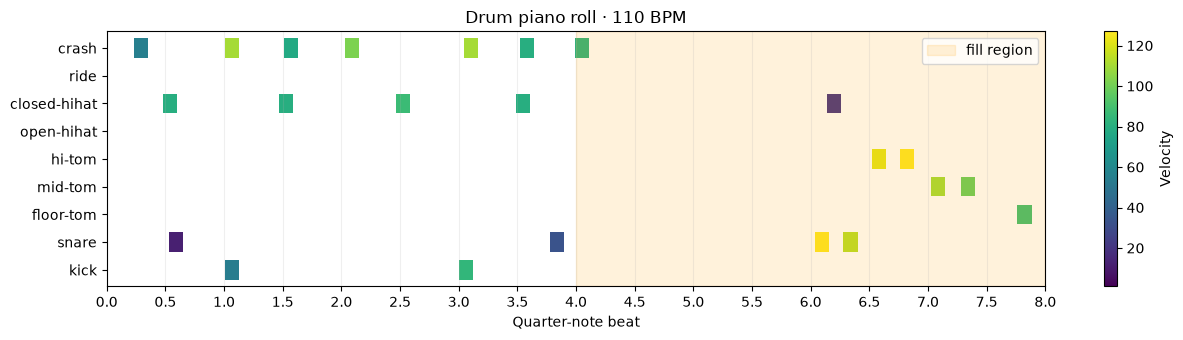

Kaynak: {'source': '10b9ddbbaddc157b81cd7be6', 'start': 2184.0, 'parent_ids': ['10b9ddbbaddc157b81cd7be6', '7558366171e31eb31973c393'], 'fill_source': '7558366171e31eb31973c393', 'fill_boundary_basis': 'inferred_next_bar_after_last_onset', 'matched_styles': ['rock'], 'style_labels': ['rock']}


In [3]:
SPLIT = 'train'
INDICES = None
N_RANDOM = 3
HAS_FILL = None

with np.load(DATASET/f'{SPLIT}.npz', allow_pickle=False) as data:
    choices = np.arange(len(data['bpm']))
    if HAS_FILL is not None:
        if 'has_fill' not in data:
            raise ValueError('Bu export fill etiketi içermiyor. HAS_FILL=None kullan veya yeniden export et.')
        choices = choices[data['has_fill'] == HAS_FILL]
selected = list(INDICES) if INDICES is not None else np.random.default_rng().choice(choices, size=min(max(0,N_RANDOM),len(choices)), replace=False).tolist()
if not selected:
    print('Bu split/filtre için örnek yok.')
for index in selected:
    result = example(DATASET, SPLIT, index=index, fill=HAS_FILL)
    if result is None:
        continue
    info, events = result
    display(Markdown(f"### {SPLIT} · örnek {index}"))
    display(pd.DataFrame([info]))
    piano_roll(events, info['bpm'], info.get('fill_start_beat'))
    plt.show()
    audio, sr = preview_audio(events, info['bpm'])
    display(Audio(audio, rate=sr, normalize=False))
    origin = provenance(DATASET, SPLIT, index)
    print('Kaynak:', {k:origin[k] for k in ('source','start','parent_ids','fill_source','fill_boundary_basis','matched_styles','style_labels') if k in origin})


## 3 · Elenenleri gör

`STAGE='canonical'`: ingest sırasında elenen/karantinaya alınan dosyalar.
`STAGE='hvo'`: export sırasında elenen dosya/pencere/kompozisyonlar.
`REASON` boşsa bütün nedenler; örneğin `missing_style`, `ambiguous_percussion`,
`collision` veya `fill_not_shorter`. Liste ilk `LIMIT` eşleşmeyi gösterir.
HVO'da bir aşamada elenmek, aynı kaynağın başka bir örnekte kullanılamadığı anlamına gelmez.


In [4]:
STAGE = 'canonical'
REASON = ''
LIMIT = 50

rejected_rows = []
if STAGE == 'canonical':
    if RUN is None:
        print('Canonical run bulunamadı; CANONICAL_RUN yolunu ayarla.')
    else:
        rejected_rows = rejected(RUN, limit=LIMIT, reason=REASON)
elif STAGE == 'hvo':
    path = DATASET/'excluded.jsonl'
    if path.exists():
        with path.open() as handle:
            for line in handle:
                item = json.loads(line)
                if REASON.lower() in item.get('reason','').lower():
                    rejected_rows.append(item)
                    if len(rejected_rows) >= LIMIT:
                        break
    else:
        print('Bu eski export detaylı HVO eleme listesi içermiyor; yeni exporter ile yeniden üretilebilir.')
else:
    raise ValueError('STAGE canonical veya hvo olmalı.')
display(pd.DataFrame([{'row':i,'file/source':r.get('relative_path',r.get('source',r.get('id'))),
                      'status':r.get('status','export stage excluded'),
                      'reason':r.get('reasons') or r.get('reason'), 'start_beat':r.get('start')}
                     for i,r in enumerate(rejected_rows)]))
print(f'{len(rejected_rows)} kayıt listelendi (gösterim sınırı: {LIMIT}).')


""


0 kayıt listelendi (gösterim sınırı: 50).


### Elenen tek bir kaydı incele

Yukarıdaki `row` değerini seç. Metadata, davul stream kararı ve gerekçeler gösterilir.
Varsa çıkarılmış davul olayları çizilir/dinlenir; hiç davul seçilmemişse ham MIDI
notaları yalnızca görselleştirilir. Eksik/değişken tempo için otomatik 120 BPM verilmez.


In [5]:
REJECTED_ROW = 0
START_BEAT = None  # None: HVO pencere başlangıcı, yoksa 0; örn. 8.0 yazılabilir.

if not rejected_rows or RUN is None:
    print('İncelenecek kayıt veya canonical run yok.')
else:
    if not 0 <= REJECTED_ROW < len(rejected_rows):
        raise ValueError('REJECTED_ROW listedeki geçerli bir row olmalı.')
    rejection = rejected_rows[REJECTED_ROW]
    display(pd.json_normalize(rejection).T)
    row = rejection if rejection.get('record') else None
    if row is None:
        source = rejection.get('source',rejection.get('id'))
        with (RUN/'manifest.jsonl').open() as handle:
            row = next((r for line in handle if (r:=json.loads(line))['id']==source),None)
    if row is None:
        print('Kaynak record bulunamadı.')
    else:
        record = read_record(RUN,row)
        display(pd.json_normalize(record.get('metadata',{})).T)
        display(pd.json_normalize(record.get('percussion_streams',[])))
        print('Metadata çelişkileri:',record.get('metadata_conflicts',[]))
        print('Web:',record.get('web_lookup'))
        drums = record.get('percussion_events',[])
        events = drums or record.get('midi',{}).get('notes',[])
        start = float(START_BEAT if START_BEAT is not None else rejection.get('start',0))
        if events:
            piano_roll(events,start=start,beats=8,title='Kaynak davul olayları' if drums else 'Ham MIDI notaları; davul seçilmemiş')
            plt.show()
        else:
            print('Parse edilmiş nota yok; hata nedenini üstte incele.')
        bpm = record.get('metadata',{}).get('tempo',{}).get('value')
        tempi = record.get('event_timeline',record.get('midi',{})).get('tempo_map',[])
        if drums and bpm and len({t['bpm'] for t in tempi}) <= 1:
            excerpt = [dict(n,onset_beat=n['onset_beat']-start) for n in drums if start<=n['onset_beat']<start+8]
            audio,sr = preview_audio(excerpt,bpm)
            display(Audio(audio,rate=sr,normalize=False))
        else:
            print('Audio atlandı: seçilmiş davul ve açık sabit tempo gerekiyor.')


İncelenecek kayıt veya canonical run yok.
